sites: [0, 892, 930, 940, 949, 1359, 2174, 3278, 3457, 3512, 3913, 5294, 5750]
x range: 1 7906
sites: [0, 892, 930, 940, 949, 1359, 2174, 3278, 3457, 3512, 3913, 5294, 5750]
sites_in_range: [892, 930, 940, 949, 1359, 2174, 3278, 3457, 3512, 3913, 5294, 5750]


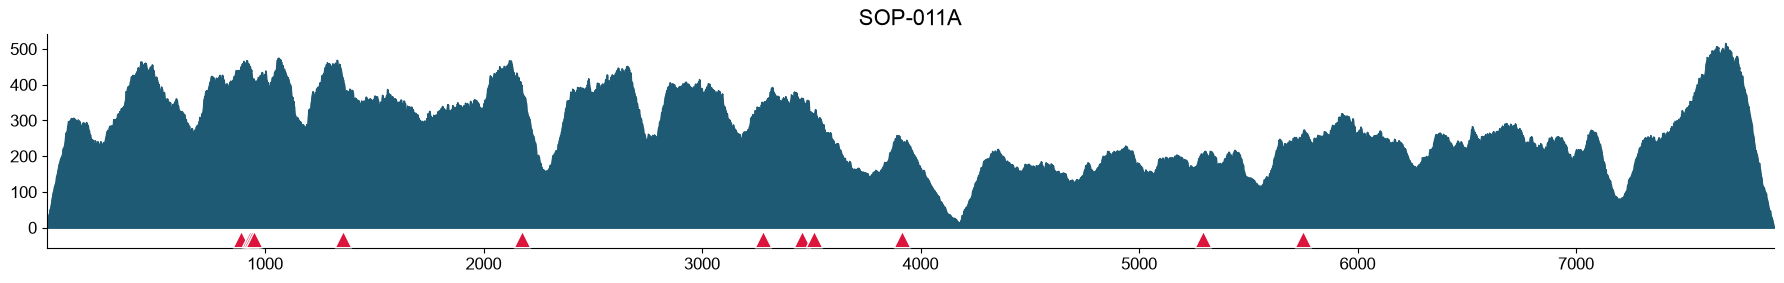

Saved: SOP-011A.with_sites.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

SITES_FILE = "2920-6.txt"
EXCEL_FILE = "Table_for_fig_6D.xlsx"
SAMPLE = "SOP-011A"
OUT = f"{SAMPLE}.with_sites.pdf"

df = pd.read_excel(EXCEL_FILE)
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
df = df.dropna(subset=["Position"])

sites_df = pd.read_csv(SITES_FILE, sep="\t", engine="python")
sites_df.columns = sites_df.columns.str.strip()  

sites = set(
    pd.to_numeric(sites_df["hpvInsertionPoint"].astype(str).str.strip(), errors="coerce")
    .dropna()
    .astype(int)
    .tolist()
)

print("sites:", sorted(list(sites)))

x = df["Position"].to_numpy()
y = pd.to_numeric(df[SAMPLE], errors="coerce").to_numpy()

fig, ax = plt.subplots(figsize=(18, 3))
ax.fill_between(x, y, color="#1f5a75")
ax.plot(x, y, color="#1f5a75", linewidth=0.8)

sites_in_range = sorted([p for p in sites if x.min() <= p <= x.max()])

print("x range:", x.min(), x.max())
print("sites:", sorted(list(sites)))
print("sites_in_range:", sites_in_range)

ymax = float(pd.Series(y).max())
arrow_y = -0.06 * ymax

ax.scatter(
    sites_in_range,
    [arrow_y] * len(sites_in_range),
    marker="^",
    s=140,
    color="crimson",
    edgecolors="white",
    linewidths=1.0,
    clip_on=False,
    zorder=10
)

ax.set_title(SAMPLE, fontsize=16)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
ax.margins(x=0)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(bottom=arrow_y * 1.8)

plt.tight_layout()
plt.savefig(OUT, dpi=300)
plt.show()
print("Saved:", OUT)